<a href="https://colab.research.google.com/github/AdenFatima/neurofive-ml-track/blob/main/neurofive_ml_track.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Exploratory Data Analysis (EDA) Summary
* **Dataset Shape:** The dataset consists of 891 rows (passengers) and 12 columns (features).
* **Data Types:** The columns are a mix of numerical features (like `Age` and `Fare`) and categorical features (like `Sex`, `Embarked`, and the target variable `Survived`).
* **Missing Values:** I identified significant missing data in three columns: `Cabin` has the most missing values (687), followed by `Age` (177), and `Embarked` (2).
* **Target Variable:** The `Survived` column indicates the outcome for each passenger and will be the primary focus for any future classification models.
* **Key Takeaway:** Before feeding this data into a machine learning model, we will need to handle the missing values—likely by imputing `Age` and `Embarked`, and potentially dropping the `Cabin` column due to severe data loss.

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('train.csv')
print("File uploaded Successfully!")

File uploaded Successfully!


In [2]:
df.head() ## Returns the first 5 rows of the dataset to get a quick look at the data structure.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.tail() # Returns the last 5 rows of the dataset to verify the end of the data.

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
df.describe() # Generates statistical summaries (mean, min, max, etc.) of all numerical columns.

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.shape # Returns a tuple showing the total number of rows and columns in the dataset.

(891, 12)

In [6]:
df.info() # Prints a concise summary including column names, data types, and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df.isnull().sum() # Calculates the total count of missing (null) values present in each column.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


### Task 2: Data Cleaning & Visualization

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Drop the 'Cabin' column entirely because 77% of its data is missing.
# axis=1 targets the column, and inplace=True applies changes directly to our dataframe.
df.drop('Cabin', axis=1, inplace=True)

In [10]:
# Fill missing values in the 'Age' column using the median (middle value) of existing ages.
# Median is used because it is safe from extreme values (outliers).
df['Age'].fillna(df['Age'].median(), inplace=True)

/tmp/ipykernel_3237/2698961543.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [11]:
# Fill the 2 missing values in 'Embarked' with the mode (the most frequently occurring port).
# We use [0] to extract just the string value from the mode result.
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_3237/1421172551.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [12]:
# Print the count of missing values again to verify that our cleaning steps worked.
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


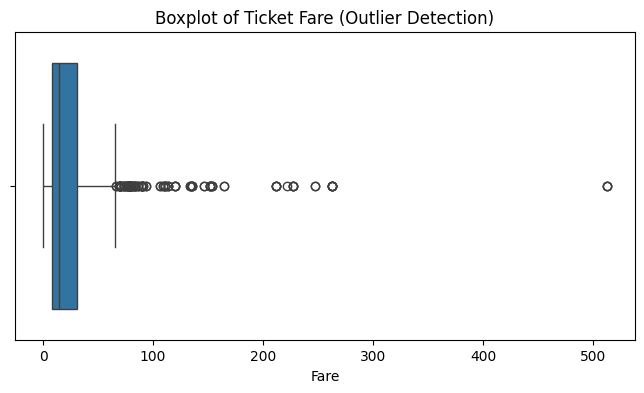

In [13]:
# Create a boxplot to spot outliers in the Fare column
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Ticket Fare (Outlier Detection)')
plt.show()

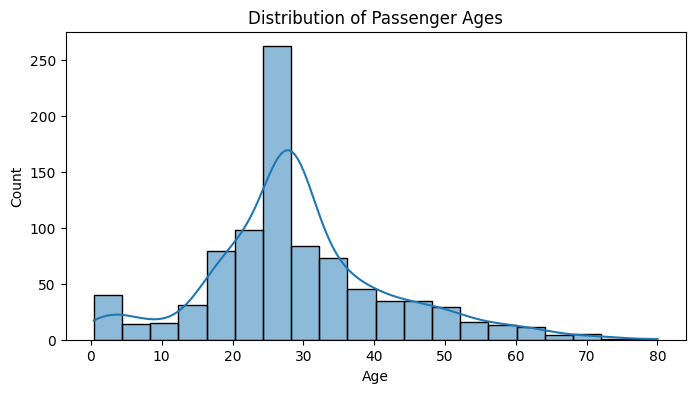

In [14]:
# Create a histogram to see the age distribution of passengers
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Distribution of Passenger Ages')
plt.show()

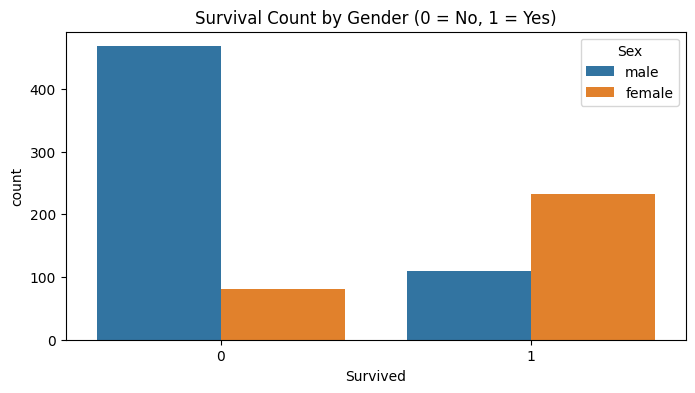

In [15]:
# Create a bar chart comparing survival rates between males and females
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Survived', hue='Sex')
plt.title('Survival Count by Gender (0 = No, 1 = Yes)')
plt.show()

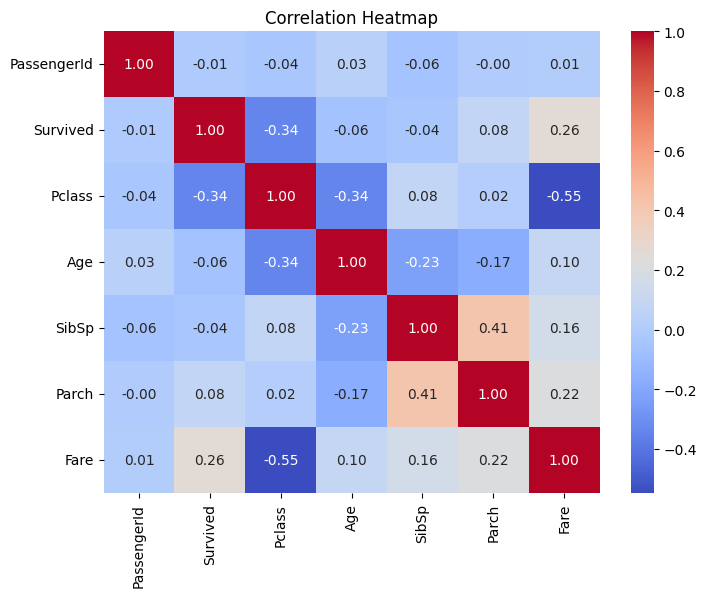

In [16]:
# Filter only numerical columns for the heatmap
numeric_cols = df.select_dtypes(include=['number'])

# Create a heatmap to show correlations between variables
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### Conclusion: Which feature most affects survival?

Based on the EDA and visualizations, **Sex (Gender)** and **Pclass (Passenger Class)** are the most significant features affecting survival.

1. **Gender:** The bar chart clearly illustrates that females had a significantly higher survival rate compared to males, reflecting the historical "women and children first" maritime protocol.
2. **Passenger Class:** The correlation heatmap shows a strong negative correlation (-0.34) between `Survived` and `Pclass`. This indicates that passengers in lower numerical classes (like 1st Class) had a much higher chance of survival compared to those in 3rd Class.

Task 3: Machine Learning Model (Logistic Regression)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [18]:
# 1. Encoding Categorical Data
# We convert text columns ('Sex' and 'Embarked') into numbers (0s and 1s).
# drop_first=True avoids the dummy variable trap (e.g., if Male=0, Female is automatically 1).
df_encoded = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

In [19]:
# We drop columns that are not useful for mathematical predictions like names and ticket numbers.
df_encoded.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

In [20]:
# 2. Define Features (X) and Target (y)
# X contains the inputs (everything except 'Survived')
# y contains the output we want to predict ('Survived')
X = df_encoded.drop('Survived', axis=1)
y = df_encoded['Survived']

In [21]:
# 3. Train/Test Split
# We split the data: 80% for training the model, and 20% for testing it later.
# random_state=42 ensures we get the exact same split every time we run the code.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# 4. Train the Logistic Regression Model
# max_iter=1000 gives the algorithm enough time to find the best mathematical fit.
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
# 5. Make Predictions and Evaluate Accuracy
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 81.01%



In [24]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[90 15]
 [19 55]]


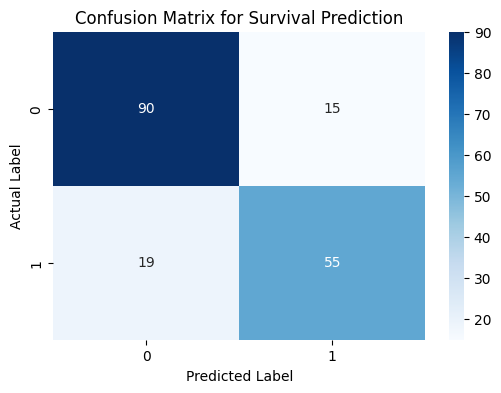

In [25]:
# Plotting the Confusion Matrix for better visualization
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Survival Prediction')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### Model Evaluation & Confusion Matrix
Our Logistic Regression model achieved an impressive **accuracy of 81.01%** on the unseen test data.

Looking at the Confusion Matrix:
* **True Negatives (90):** Passengers correctly predicted as not survived.
* **True Positives (55):** Passengers correctly predicted as survived.
* **False Positives (15):** The model incorrectly guessed they survived.
* **False Negatives (19):** The model incorrectly guessed they did not survive.

Overall, the model performed very well, proving that the features we selected and cleaned (like Sex and Pclass) are strong indicators of survival.

### Task 5: Model Evaluation & Hyperparameter Tuning

In [26]:
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [27]:
# PART 1: ORIGINAL MODEL EVALUATION
# Using the 'predictions' and 'y_test' variables you already have from Task 3
print("--- CLASSIFICATION REPORT (BEFORE TUNING) ---")
print(classification_report(y_test, predictions))

--- CLASSIFICATION REPORT (BEFORE TUNING) ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [28]:
# PART 2: HYPERPARAMETER TUNING (GridSearchCV)
# We define different settings ('dials') for the model to test
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],            # C is regularization strength
    'solver': ['liblinear', 'lbfgs']         # Solvers are different math algorithms
}

print("Running GridSearchCV to find the best settings... Please wait.\n")
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

Running GridSearchCV to find the best settings... Please wait.



GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [29]:
# PART 3: TUNED MODEL (AFTER TUNING)
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)

print("--- CLASSIFICATION REPORT (AFTER TUNING) ---")
print(f"Best Parameters Found: {grid_search.best_params_}")
print(classification_report(y_test, y_pred_tuned))

--- CLASSIFICATION REPORT (AFTER TUNING) ---
Best Parameters Found: {'C': 1, 'solver': 'liblinear'}
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [30]:
# PART 4: SIMPLE COMPARISON
print("--- COMPARISON SUMMARY ---")
# Using the 'accuracy' variable from your Task 3
print(f"Original Accuracy: {accuracy * 100:.2f}%")
print(f"Tuned Accuracy:    {acc_tuned * 100:.2f}%")

--- COMPARISON SUMMARY ---
Original Accuracy: 81.01%
Tuned Accuracy:    78.21%


### Why Accuracy Can Be Misleading
Accuracy alone can lie to us, especially when dealing with **imbalanced datasets**. For example, if a dataset has 99 normal transactions and 1 fraudulent transaction, a "dumb" model that predicts "Normal" every single time will achieve 99% accuracy. However, it completely fails its actual job: catching the fraud.

That is why we use metrics like **Precision** (how many predicted positive cases were actually positive) and **Recall** (how many actual positive cases the model managed to find). The **F1-Score** combines both to give us a much more realistic picture of the model's true performance.